### Avoided Gas Capacity
This notebook attempts to calculate how much gas plant capacity can be avoided if solar were cheap. We rely on the *As Cheap As Our Peers* estimate of ~200 GW of *additional* residential rooftop solar capacity installed by 2040 as a starting point. 

#### Methodology
1) Take state-level aggregate hourly loads from the baseline dGen run (current solar prices) for 2040 and compare to policy dGen run ($1/watt) to get annual difference in generation
2) Assume 75 percent of the difference in generation would have been met with CCGT
3) Using a capacity factor of .56, Calculate the equivalent gas capacity needed to meet the gas-attributable difference in generation
4) Divide this GW figure by .9 to estimate the number of avoided gas plants

In [1]:
import sys,os
from pathlib import Path

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from avoided_gas_capacity import compute_natgas_capacity_equivalent, plot_weekly_national_load, plot_smoothed_daily_national_load



In [2]:
# Base directory where the per-state hourly outputs are stored.
STATE_OUTPUT_BASE = Path("/Volumes/Seagate Portabl/permit_power/dgen_runs/per_state_outputs")

# Path to the natural gas generation share CSV.
GAS_SHARE_CSV = Path("../data/natural_gas_generation_share_state.csv")

# List of states to include in the analysis.
# This example uses the 48 contiguous states; adjust as needed.
STATES = [
    "AL", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "IA", "ID", "IL", "IN", "KS",
    "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO", "MS", "MT", "NC", "ND", "NE", "NH",
    "NJ", "NM", "NV", "NY", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT",
    "VA", "VT", "WA", "WI", "WV", "WY",
]

# Target modeling year in the state_hourly CSVs.
TARGET_YEAR = 2040

# Year used to compute natural gas generation shares.
GAS_SHARE_YEAR = 2024

# Capacity factor used to convert annual gas MWh displaced to equivalent MW/GW.
# Source: https://www.eia.gov/todayinenergy/detail.php?id=61444
GAS_CAPACITY_FACTOR = 0.56

# Marginal share of generation attributable to gas plants
MARGINAL_GAS_SHARE = 0.75

# Scenario names used in the filenames: {scenario}_state_hourly.csv
BASELINE_SCENARIO = "baseline"
POLICY_SCENARIO = "policy"

# Path template for the state-hourly files.
STATE_HOURLY_PATH_TEMPLATE = (
    str(STATE_OUTPUT_BASE)
    + "/{state_abbr}/run_all_states_net_savings_adjust_loan_params/"
    + "{scenario}_state_hourly.csv"
)

In [3]:
state_results_marginal, national_summary_marginal = compute_natgas_capacity_equivalent(
    states=STATES,
    gas_share_csv_path=None,         
    target_year=TARGET_YEAR,
    gas_share_year=GAS_SHARE_YEAR,    
    capacity_factor=GAS_CAPACITY_FACTOR,          
    baseline_scenario=BASELINE_SCENARIO,
    policy_scenario=POLICY_SCENARIO,
    state_hourly_path_template=STATE_HOURLY_PATH_TEMPLATE,
    clip_negative_deltas=True,
    gas_share_mode="fixed_fraction", 
    fixed_gas_share=MARGINAL_GAS_SHARE,  
)

In [4]:
display(national_summary_marginal)

print(
    f"Equivalent natural gas capacity at CF={GAS_CAPACITY_FACTOR:.2f}: "
    f"{national_summary_marginal['gas_capacity_equiv_gw']:.2f} GW"
)


delta_mwh_total          1.173558e+08
gas_mwh_displaced        8.801682e+07
gas_capacity_equiv_mw    1.794211e+04
gas_capacity_equiv_gw    1.794211e+01
dtype: float64

Equivalent natural gas capacity at CF=0.56: 17.94 GW


/Users/talorgruenwald/src/permit_power/ad_hoc/src/avoided_gas_capacity.py:949: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(start=start, periods=len(baseline_nat), freq="H")


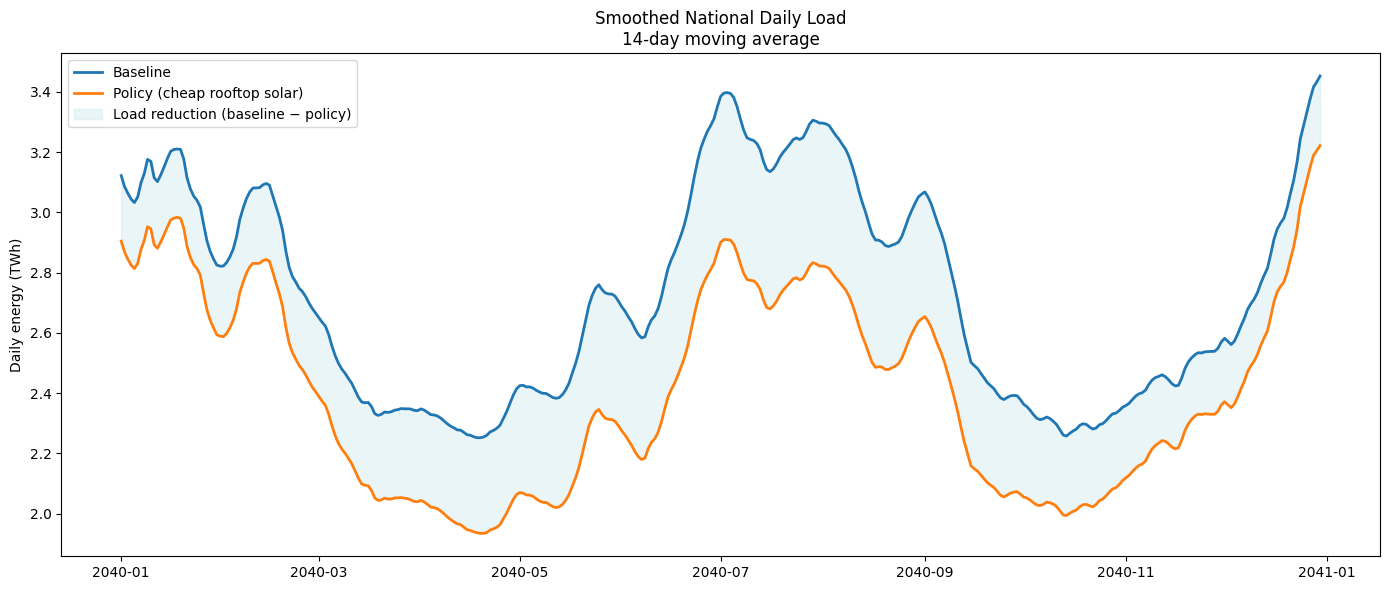

In [5]:
plot_smoothed_daily_national_load(
    states=STATES,
    target_year=2040,
    baseline_scenario=BASELINE_SCENARIO,
    policy_scenario=POLICY_SCENARIO,
    state_hourly_path_template=STATE_HOURLY_PATH_TEMPLATE,
    ma_window_days=14,       
    figsize=(14, 6),
    energy_units="TWh" 
)